In [1]:
import mrcfile
import numpy as np
import matplotlib.pyplot as plt

from panther_em.utils.polar_transform import warp_polar_inverse
from panther_em.utils.project_polar import get_polar_projections_from_volume

In [2]:
volume_path = "/Users/mgiammar/Documents/tt2DTM/scratch_files/data/lsu.mrc"
volume = mrcfile.read(volume_path)
volume.shape, type(volume)

((512, 512, 512), numpy.ndarray)

In [3]:
phi = np.linspace(0, 180, 37, endpoint=False)
theta = np.linspace(0, 180, 37, endpoint=False)
projections = get_polar_projections_from_volume(
    volume,
    phi=phi,
    theta=theta,
)
projections.shape

DEBUG - angles_shape: (37,)


(37, 360, 363)

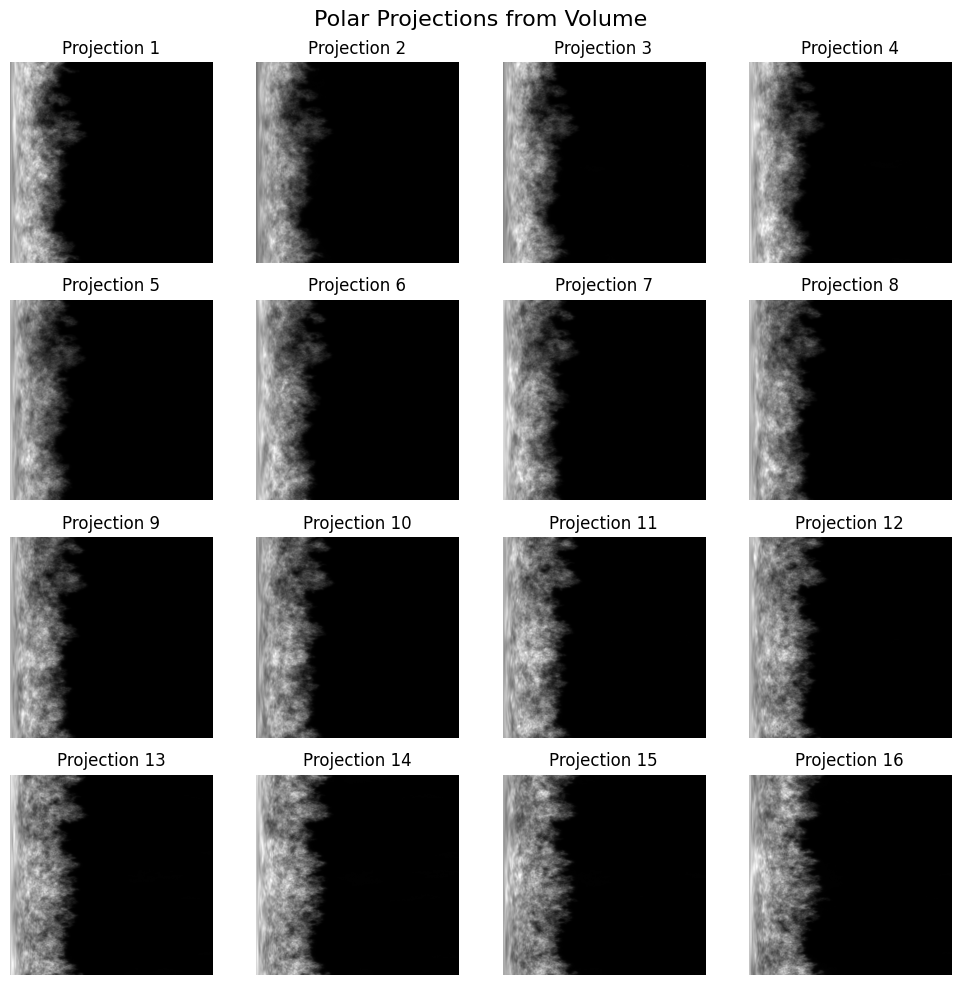

In [4]:
# Plot the first 16 projections
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(projections[i], cmap="gray")
    ax.set_title(f"Projection {i+1}")
    ax.axis("off")
fig.suptitle("Polar Projections from Volume", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# Take the projections from (b, angle, radius) to (angle, radius, b) so multi-channel
# transforms images together
projections = np.transpose(projections, (1, 2, 0))

inverse_projections = warp_polar_inverse(
    projections,
    output_shape=(volume.shape[1], volume.shape[2]),
    scaling="linear",
    multichannel=True,
)

inverse_projections = np.transpose(inverse_projections, (2, 0, 1))
inverse_projections.shape

(37, 512, 512)

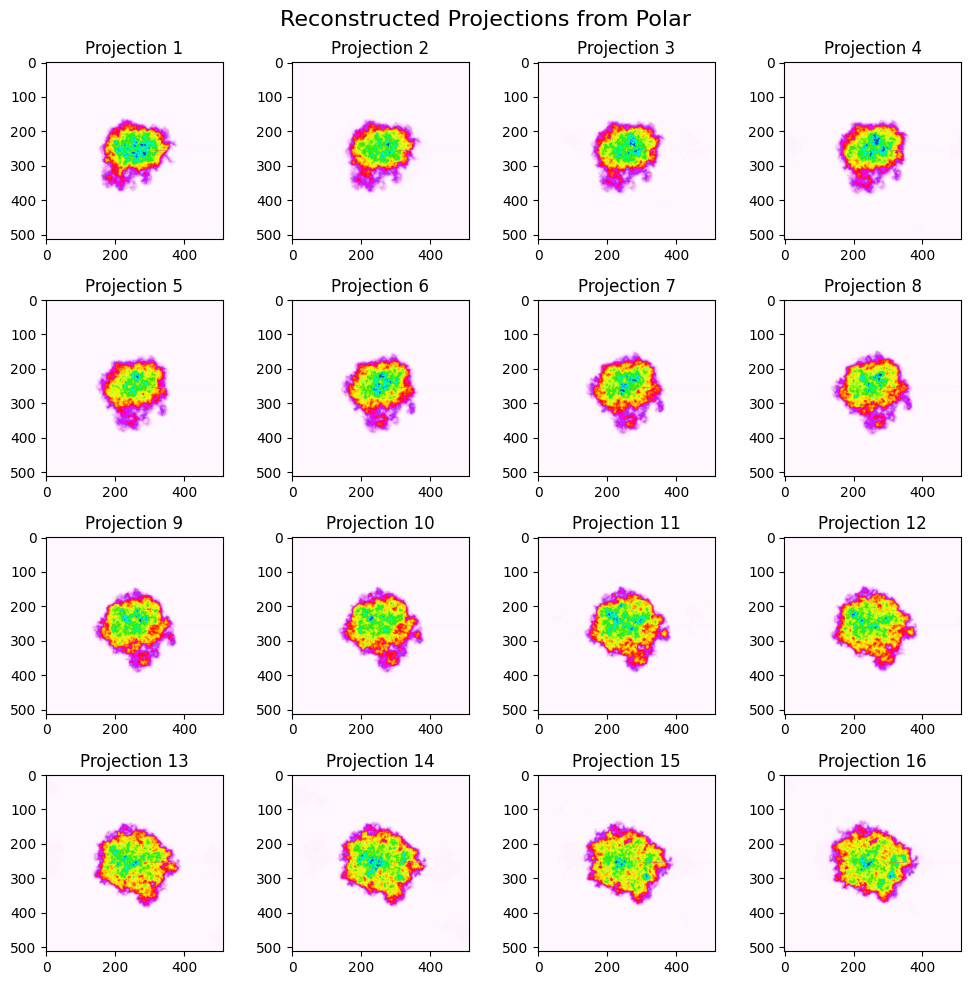

In [8]:
# Plot the first 16 reinverted projections
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(inverse_projections[i], cmap="gist_ncar_r")
    ax.set_title(f"Projection {i+1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()